## 2 Regression Analysis

Predict the price of the Uber ride from a given pickup point to the agreed drop-off
location. Perform following tasks:
1. Pre-process the dataset.
2. Identify outliers.
3. Check the correlation.
4. Implement linear regression and ridge, Lasso regression models.
5. Evaluate the models and compare their respective scores like R2, RMSE, etc.
Dataset link: https://www.kaggle.com/datasets/yasserh/uber-fares-dataset

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
df= pd.read_csv('uber.csv')
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


## 1. Preprocess dataset

In [75]:
df.shape

(200000, 9)

In [76]:
df.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


## About Dataset

| Column Name        | Description                                      | Data Type          | Example Value              |
|--------------------|------------------------------------------------|--------------------|----------------------------|
| Unnamed: 0         | Index or unique identifier for each record      | Integer            | 0, 1, 2, ...               |
| key                | Unique ride identifier or timestamp              | String / Timestamp | 2015-05-07 19:52:06.0000003|
| fare_amount        | The price paid for the Uber ride (target variable) | Float              | 7.5, 7.7, 12.9             |
| pickup_datetime    | Timestamp of when the ride started               | Datetime           | 2015-05-07 19:52:06 UTC    |
| pickup_longitude   | Longitude coordinate of the pickup location      | Float              | -73.999817                 |
| pickup_latitude    | Latitude coordinate of the pickup location       | Float              | 40.738354                  |
| dropoff_longitude  | Longitude coordinate of the drop-off location    | Float              | -73.999512                 |
| dropoff_latitude   | Latitude coordinate of the drop-off location     | Float              | 40.723217                  |
| passenger_count    | Number of passengers in the Uber ride             | Integer            | 1, 3, 5                    |


In [78]:
df.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [79]:
# Checking null values
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

As we see their are only two null vlaues, so we can drop them directly

In [80]:
df.dropna(inplace=True)

In [81]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [82]:
# Checking duplicate entries
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
199995    False
199996    False
199997    False
199998    False
199999    False
Length: 199999, dtype: bool

In [83]:
# Their arre columns Unnamed and key , they does't add importance will drop them
df.drop(["key","Unnamed: 0"],axis =1, inplace = True) 

In [84]:
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [85]:
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'])
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5


## calculating distance from latitude and longitude

In [86]:
def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)
    
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    a = np.sin(dlat/2)**2 + np.cos(lat1_rad)*np.cos(lat2_rad)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

In [87]:
# Feature engineering: Calculate trip distance
df['distance_km'] = calculate_distance(df['pickup_latitude'], df['pickup_longitude'],
                                      df['dropoff_latitude'], df['dropoff_longitude'])


In [88]:
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683323
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457590
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036377
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661683
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475450


In [89]:
# Extract datetime features if datetime exists
df['year'] = df['pickup_datetime'].dt.year
df['month'] = df['pickup_datetime'].dt.month
df['day'] = df['pickup_datetime'].dt.day
df['hour'] = df['pickup_datetime'].dt.hour

In [90]:
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,year,month,day,hour
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683323,2015,5,7,19
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457590,2009,7,17,20
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036377,2009,8,24,21
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661683,2009,6,26,8
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475450,2014,8,28,17


now we have converted datetime column into separate columns as year month day daysofweek and hours

In [91]:
df = df.drop(columns=['pickup_datetime'])

In [92]:
df.head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,year,month,day,hour
0,7.5,-73.999817,40.738354,-73.999512,40.723217,1,1.683323,2015,5,7,19
1,7.7,-73.994355,40.728225,-73.994710,40.750325,1,2.457590,2009,7,17,20
2,12.9,-74.005043,40.740770,-73.962565,40.772647,1,5.036377,2009,8,24,21
3,5.3,-73.976124,40.790844,-73.965316,40.803349,3,1.661683,2009,6,26,8
4,16.0,-73.925023,40.744085,-73.973082,40.761247,5,4.475450,2014,8,28,17


## 2. Identify outliers

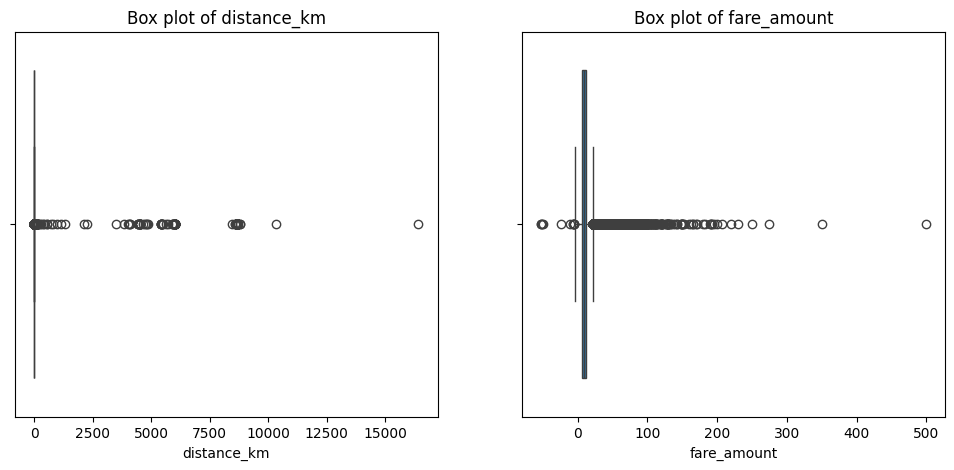

In [93]:
plt.figure(figsize=(12, 5))

# Box plot for distance_km
plt.subplot(1, 2, 1)
sns.boxplot(x=df['distance_km'])
plt.title('Box plot of distance_km')

# Box plot for fare_amount
plt.subplot(1, 2, 2)
sns.boxplot(x=df['fare_amount'])
plt.title('Box plot of fare_amount')

plt.show()


In [94]:
# Using IQR for distance and price
Q1_dist = df['distance_km'].quantile(0.25)
Q3_dist = df['distance_km'].quantile(0.75)
IQR_dist = Q3_dist - Q1_dist

Q1_price = df['fare_amount'].quantile(0.25)
Q3_price = df['fare_amount'].quantile(0.75)
IQR_price = Q3_price - Q1_price

outlier_dist = ((df['distance_km'] < (Q1_dist - 1.5 * IQR_dist)) | (df['distance_km'] > (Q3_dist + 1.5 * IQR_dist)))
outlier_price = ((df['fare_amount'] < (Q1_price - 1.5 * IQR_price)) | (df['fare_amount'] > (Q3_price + 1.5 * IQR_price)))

print(f"Outliers in distance: {outlier_dist.sum()}")
print(f"Outliers in fare_amount: {outlier_price.sum()}")

Outliers in distance: 16755
Outliers in fare_amount: 17166


## 3. Check correlation

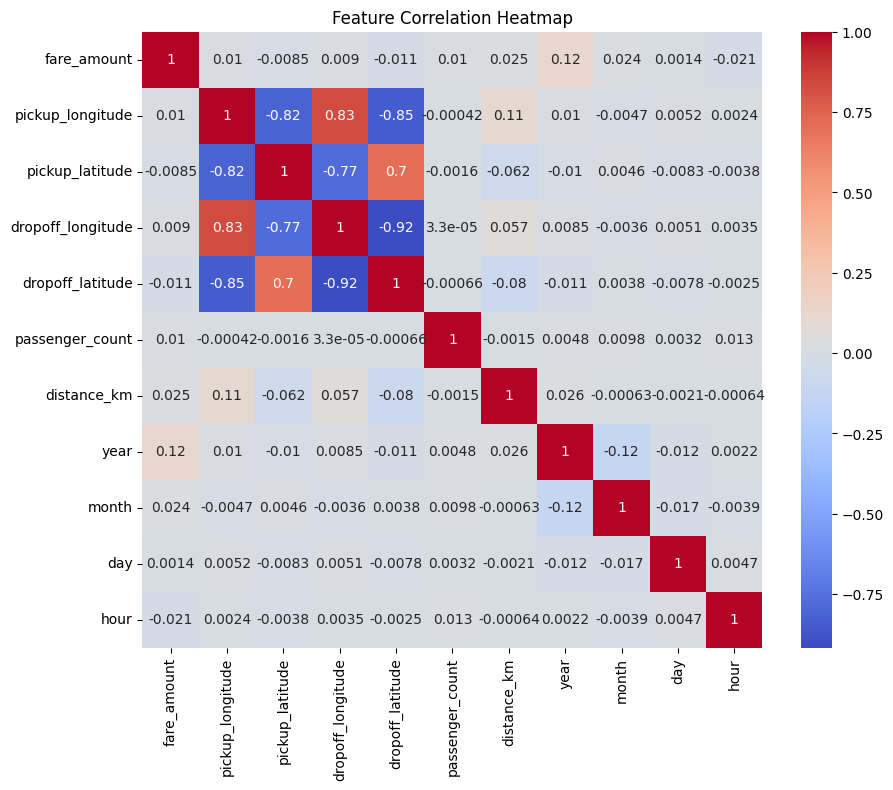

In [95]:
# 3. Check correlation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

Based on the heatmap:

The newly added distance_km column shows a moderate positive correlation with fare_amount. This indicates that longer trips (higher distance_km) tend to have higher fares, which is a logical and useful relationship for predicting fare amount.
The datetime features (year, month, day, hour), which were extracted from the pickup_datetime column, show very weak correlation with fare_amount. This suggests that, individually, the year, month, day, and hour of the pickup do not have a strong linear relationship with the fare amount in this dataset. While they might capture some non-linear patterns or interactions not visible in the correlation matrix, their direct linear correlation with the fare is minimal.

## 4. Prepare data for modeling

In [96]:
X = df.drop(columns=['fare_amount'])
y = df['fare_amount']

In [99]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [57]:
# Standardize features for Ridge/Lasso
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [100]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## LinearRegression

In [101]:
l_model=LinearRegression()

In [102]:
l_model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [103]:
l_model.score(x_test,y_test)

0.016794565777115467

In [104]:
y_pred_lr = l_model.predict(x_test)

lr_mse = np.sqrt(mean_squared_error(y_pred_lr, y_test))
print("RMSE value for Linear regression is:", lr_mse)

RMSE value for Linear regression is: 10.11320410665126


## Random Forest Regressor

In [107]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators = 20, random_state = 101)
rfr.fit(x_train,y_train)
y_pred_rfr = rfr.predict(x_test)

rfr_mse = np.sqrt(mean_squared_error(y_pred_rfr, y_test))

print("RMSE Value for Random Forest Regression is:", rfr_mse) #---> lower the  value , closer to the prediction

RMSE Value for Random Forest Regression is: 5.361986900906636


In [109]:
rfr.score(x_test,y_test)*100

72.3612611151107

Comparing above two models , Random Forest Regressor is performing Better

##  Ridge Regression

In [114]:
ridge = Ridge(alpha=1.0, random_state=101)
ridge.fit(x_train, y_train)
y_pred_ridge = ridge.predict(x_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression -> RMSE: {rmse_ridge:.4f}")

Ridge Regression -> RMSE: 10.1132


## Lasso Regression

In [115]:
lasso = Lasso(alpha=0.1, random_state=101)
lasso.fit(x_train, y_train)
y_pred_lasso = lasso.predict(x_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression -> RMSE: {rmse_lasso:.4f}")

Lasso Regression -> RMSE: 10.1143


`Ridge regression` is used to handle multicollinearity (when features are highly correlated) and prevent overfitting by keeping all features but shrinking their impact.

`Lasso regression` is used when you want to simplify the model by selecting important features, since it can set some coefficients exactly to zero, making the model easier to interpret.

Both improve model performance and generalization compared to plain linear regression.

## Conclusion

In this practical, we performed regression analysis to predict the fare amount of Uber rides.

1. **Data Preprocessing:** We loaded the dataset, handled missing values by dropping rows, removed irrelevant columns (`key` and `Unnamed: 0`), converted the `pickup_datetime` to a datetime object, and extracted relevant features like year, month, day, and hour. We also calculated the distance of each trip using latitude and longitude coordinates.

2. **Outlier Identification:** We identified outliers in `distance_km` and `fare_amount` using the Interquartile Range (IQR) method, noting the significant number of outliers in both features.

3. **Correlation Analysis:** A heatmap was generated to visualize the correlation between features. It showed a moderate positive correlation between `fare_amount` and `distance_km`, as expected. Other features like `passenger_count` and datetime components showed weak correlations with the fare amount.

4. **Model Implementation and Evaluation:** We implemented and evaluated three regression models: Linear Regression, Random Forest Regressor, Ridge Regression, and Lasso Regression.

   - **Linear Regression:** Showed a low R2 score (around 0.017) and a high RMSE (around 10.11), indicating a poor fit to the data.
   - **Random Forest Regressor:** Significantly outperformed Linear Regression, achieving a much higher R2 score (around 0.724) and a lower RMSE (around 5.36).
   - **Ridge and Lasso Regression:** Both Ridge and Lasso regressions performed similarly to Linear Regression with low R2 scores and high RMSE values, suggesting that regularization with the current features and alpha values did not significantly improve the linear model's performance.

Based on the evaluation metrics, the **Random Forest Regressor** model performed the best among the tested models for predicting Uber fare amounts on this dataset.

Further improvements could involve handling outliers, exploring feature engineering techniques (e.g., one-hot encoding for categorical time features, considering peak hours or special events), and hyperparameter tuning for the models, especially for the Random Forest and the regularization parameters in Ridge and Lasso.